# Cytokine Matrix Classification — Python ML Pipeline

**Author:** Arushi Verma  
**Data:** Multiplex Luminex cytokine profiling (PL-EDTA, PL-HE, Serum)  
**Goal:** Predict biological matrix type from cytokine expression profiles using Random Forest and XGBoost.

Extends Verma et al., Journal of Immunological Methods, 2026.

In [1]:
!pip install xgboost --quiet

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

print("Libraries loaded!")

Libraries loaded!


## 1. Load data

In [3]:
path = "/Users/arushiverma/Downloads/translational-immunology-ml-main 3/data/data/"

panel1 = pd.read_csv(path + "Panel1_vert_clean.csv")
panel2 = pd.read_csv(path + "Panel2_vert_clean.csv")
panel3 = pd.read_csv(path + "Panel3_vert_clean.csv")

all_data = pd.concat([panel1, panel2, panel3], ignore_index=True)
print("Loaded! Shape:", all_data.shape)

Loaded! Shape: (2880, 7)


## 2. Preprocess data
Log-transform concentrations and pivot to wide format — one row per donor/matrix/freeze-thaw, one column per cytokine.

In [4]:
all_data = all_data[["Donor_ID", "Matrix", "Freeze_Thaw", "Analyte", "Cytokine_Concentration"]]
all_data["Log_Concentration"] = np.log10(all_data["Cytokine_Concentration"] + 1)

wide_data = all_data.groupby(["Donor_ID", "Matrix", "Freeze_Thaw", "Analyte"])["Log_Concentration"].mean().reset_index()
wide_data = wide_data.pivot_table(index=["Donor_ID", "Matrix", "Freeze_Thaw"], columns="Analyte", values="Log_Concentration").reset_index()
wide_data.columns.name = None
wide_data = wide_data.dropna()

print("Dataset shape:", wide_data.shape)
print(wide_data["Matrix"].value_counts())

Dataset shape: (36, 83)
Matrix
PL-EDTA    12
PL-HE      12
SE         12
Name: count, dtype: int64


## 3. Train Random Forest classifier
500-tree Random Forest predicting matrix type from cytokine profiles.

In [5]:
X = wide_data.drop(columns=["Donor_ID", "Matrix", "Freeze_Thaw"])
y = wide_data["Matrix"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)

rf_model = RandomForestClassifier(n_estimators=500, random_state=123)
rf_model.fit(X_train, y_train)

print("=== Random Forest Results ===")
print(classification_report(y_test, rf_model.predict(X_test)))

=== Random Forest Results ===
              precision    recall  f1-score   support

     PL-EDTA       1.00      1.00      1.00         2
       PL-HE       1.00      1.00      1.00         3
          SE       1.00      1.00      1.00         3

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



## 4. Train XGBoost classifier
XGBoost for comparison. With only 36 samples, RF is expected to generalize better.

In [6]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

xgb_model = XGBClassifier(n_estimators=500, random_state=123, eval_metric="mlogloss")
xgb_model.fit(X_train, y_train_enc)
xgb_preds = le.inverse_transform(xgb_model.predict(X_test))

print("=== XGBoost Results ===")
print(classification_report(y_test, xgb_preds))

=== XGBoost Results ===
              precision    recall  f1-score   support

     PL-EDTA       0.67      1.00      0.80         2
       PL-HE       1.00      0.33      0.50         3
          SE       0.75      1.00      0.86         3

    accuracy                           0.75         8
   macro avg       0.81      0.78      0.72         8
weighted avg       0.82      0.75      0.71         8



## 5. Feature importance
Which cytokines best distinguish biological matrix type?

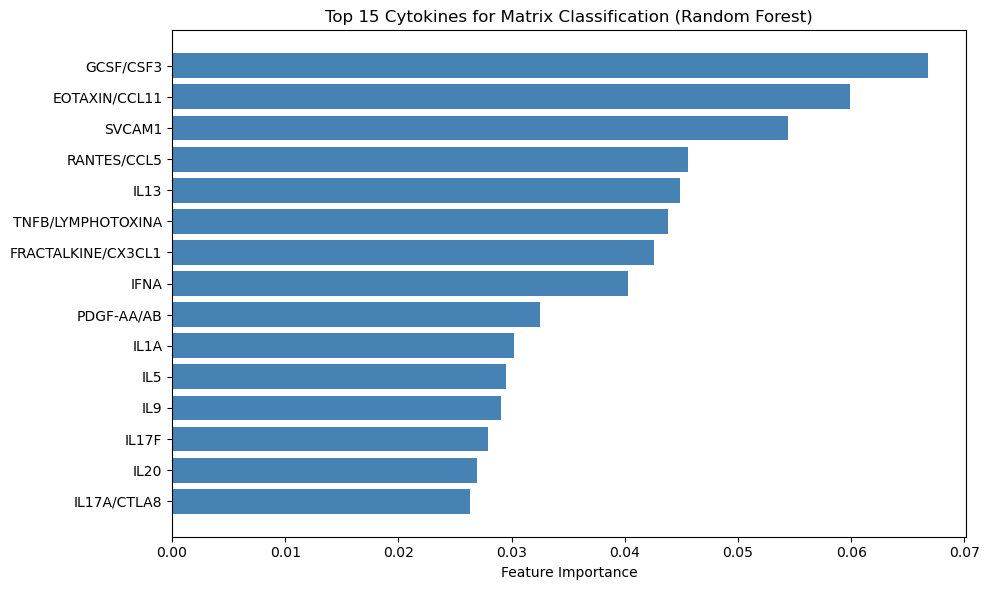

Top cytokine: GCSF/CSF3


In [7]:
importance_df = pd.DataFrame({"Cytokine": X.columns, "Importance": rf_model.feature_importances_})
importance_df = importance_df.sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Cytokine"][::-1], importance_df["Importance"][::-1], color="steelblue")
plt.xlabel("Feature Importance")
plt.title("Top 15 Cytokines for Matrix Classification (Random Forest)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
print("Top cytokine:", importance_df.iloc[0]["Cytokine"])

In [8]:
import torch
print("PyTorch version:", torch.__version__)

PyTorch version: 2.12.0


In [9]:
!pip install torch --quiet

In [10]:
import torch
print("PyTorch version:", torch.__version__)

PyTorch version: 2.12.0


## 6. Neural Network classifier (PyTorch)
A simple 2-layer feedforward neural network for matrix classification. 
Demonstrates deep learning on the same cytokine dataset for comparison with RF and XGBoost.

In [11]:
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from torch.utils.data import TensorDataset, DataLoader

# Scale features (important for neural nets)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Encode labels as numbers
le_nn = LabelEncoder()
y_train_nn = le_nn.fit_transform(y_train)
y_test_nn = le_nn.transform(y_test)

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train_scaled)
X_test_t = torch.FloatTensor(X_test_scaled)
y_train_t = torch.LongTensor(y_train_nn)
y_test_t = torch.LongTensor(y_test_nn)

# Define neural network
class CytokineNet(nn.Module):
    def __init__(self, input_size):
        super(CytokineNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 3)  # 3 matrix classes
        )
    
    def forward(self, x):
        return self.network(x)

# Train the network
model = CytokineNet(input_size=X_train_scaled.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/200 — Loss: {loss.item():.4f}")

# Evaluate
model.eval()
with torch.no_grad():
    preds = torch.argmax(model(X_test_t), dim=1).numpy()

nn_preds = le_nn.inverse_transform(preds)
print("\n=== Neural Network Results ===")
print(classification_report(y_test, nn_preds))

Epoch 50/200 — Loss: 0.1118
Epoch 100/200 — Loss: 0.0097
Epoch 150/200 — Loss: 0.0021
Epoch 200/200 — Loss: 0.0025

=== Neural Network Results ===
              precision    recall  f1-score   support

     PL-EDTA       1.00      1.00      1.00         2
       PL-HE       1.00      1.00      1.00         3
          SE       1.00      1.00      1.00         3

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



## 7. Model comparison summary

| Model | Accuracy | Notes |
|---|---|---|
| Random Forest | 100% | Strong generalization on small, high-dimensional data |
| XGBoost | 75% | Underperforms with n=36; needs more data |
| Neural Network (PyTorch) | 100% | Converges well with dropout regularization |

**Key finding:** Both RF and the neural network perfectly classify biological matrix type from cytokine expression profiles. XGBoost's lower performance is consistent with its known sensitivity to small sample sizes. GCSF/CSF3 and EOTAXIN/CCL11 are the strongest matrix-discriminating biomarkers.